# Problem Set 1 — Exercise 2

This notebook generalizes the on-grid value function iteration code from Session 2 to CRRA utility and partial depreciation.

The model is

$
u(c)=
\begin{cases}
\dfrac{c^{1-\gamma}-1}{1-\gamma}, & \gamma\neq1,\\
\log c, & \gamma=1,
\end{cases}
$

with resource constraint

$
c+k'=k^\alpha+(1-\delta)k.
$

The benchmark case $\gamma=1,\delta=1$ is first used to verify the generalized code against the analytical solution. We then solve the model for $\gamma=2,\delta=0.1$.

### 0. Packages

Plotting and formatted printing. Nothing else is needed today.

In [1]:
using Plots
using Printf

### 1. Parameters: economics

One container for the economics, one for the numerics (week 1 primer, part 3).
Keeping them apart makes the experiments at the end safe: when you change the
grid, you can see at a glance that no economics moved.

The economic parameters are the capital share $\alpha$ and the discount factor
$\beta$, to which we now added $\gamma$ and $\delta$. Utility is CRRA, with $\gamma=1$ giving log utility.

In [2]:
Base.@kwdef struct EconomicParameters
    α::Float64 = 0.3
    β::Float64 = 0.96
    γ::Float64 = 1.0
    δ::Float64 = 1.0
end

EconomicParameters

### 1. Parameters: numerics

Everything that belongs to the *method* and not to the *model*: the number of
grid points $N$, the grid bounds relative to the steady state $k^*$, the spacing
of the points, the tolerance $\varepsilon$, and the iteration cap $\overline{n}$.

In [3]:
Base.@kwdef struct NumericalParameters
    nk::Int = 200             # number of points on the capital grid, N
    kmin_rel::Float64 = 0.1   # lower grid bound, relative to k*
    kmax_rel::Float64 = 2.0   # upper grid bound, relative to k*
    spacing::Symbol = :linear # :linear or :log
    crit::Float64 = 1e-6      # convergence tolerance, ε
    maxiter::Int = 5000       # iteration cap, the safety net
end

NumericalParameters

### 3. The utility function

CRRA utility from the problem set.

In [4]:
function util(c, γ)
    if γ == 1.0
        return log(c)
    else
        return (c^(1 - γ) - 1) / (1 - γ)
    end
end

util (generic function with 1 method)

In [5]:
function solve_vfi(par, mpar)

    println(
        "Value function iteration with parameters ",
        "alpha = $(par.α), beta = $(par.β), gamma = $(par.γ), ",
        "delta = $(par.δ), N = $(mpar.nk), crit = $(mpar.crit)"
    )

    # Steady state and grid
    kstar = (par.α / (1 / par.β - 1 + par.δ))^(1 / (1 - par.α))
    kmin = mpar.kmin_rel * kstar
    kmax = mpar.kmax_rel * kstar

    if mpar.spacing == :linear
        K = collect(range(kmin, kmax, length = mpar.nk))
    else
        K = exp.(range(log(kmin), log(kmax), length = mpar.nk))
    end

    # Meshes
    mesh_k = [k for k in K, kp in K]
    mesh_kprime = [kp for k in K, kp in K]

    # Consumption matrix
    C = mesh_k.^par.α .+ (1 - par.δ) .* mesh_k .- mesh_kprime

    # Reward matrix
    U = fill(-Inf, size(C))
    U[C .> 0] = util.(C[C .> 0], par.γ)

    # Value function iteration
    timer = time_ns()

    v = zeros(mpar.nk)
    g = ones(Int, mpar.nk)
    distVF = [Inf]
    iterVF = 0

    while distVF[end] > mpar.crit && iterVF < mpar.maxiter
        M = U .+ par.β .* v'

        vals, idx = findmax(M, dims = 2)
        vnew = vec(vals)
        g = vec(getindex.(idx, 2))

        dd = maximum(abs.(vnew .- v))

        v = vnew
        iterVF += 1
        push!(distVF, dd)
    end

    time_vfi = (time_ns() - timer) / 1e9

    if distVF[end] > mpar.crit
        error("not converged: the iteration cap was hit")
    end

    # Policy in levels and consumption
    kprime = K[g]
    c = K.^par.α .+ (1 - par.δ) .* K .- kprime

    @printf(
        "iterations: %d, final distance: %.3e, time: %.3f s\n",
        iterVF, distVF[end], time_vfi
    )

    println("policy at the lowest grid point:  ", count(g .== 1), " states")
    println("policy at the highest grid point: ", count(g .== mpar.nk), " states")

    return (
        K = K,
        kstar = kstar,
        v = v,
        g = g,
        kprime = kprime,
        c = c,
        distVF = distVF,
        iterations = iterVF,
        runtime = time_vfi
    )
end

solve_vfi (generic function with 1 method)

In [6]:
function euler_errors(sol, par)

    K = sol.K
    g = sol.g
    c = sol.c
    kprime = sol.kprime

    cprime = c[g]

    R = par.α .* kprime.^(par.α - 1) .+ 1 .- par.δ

    e = 1 .- (par.β .* R).^(-1 / par.γ) .* (cprime ./ c)

    return e
end

euler_errors (generic function with 1 method)

In [7]:
function print_parameters(par, mpar, sol)
    println(
        "Value function iteration with parameters ",
        "alpha = $(par.α), beta = $(par.β), gamma = $(par.γ), ",
        "delta = $(par.δ), N = $(mpar.nk), crit = $(mpar.crit)"
    )

    @printf(
        "iterations: %d, final distance: %.3e\n",
        sol.iterations, sol.distVF[end]
    )

    println(
        "policy at the lowest grid point: ",
        count(sol.g .== 1), " states"
    )
    println(
        "policy at the highest grid point: ",
        count(sol.g .== mpar.nk), " states"
    )
end

print_parameters (generic function with 1 method)

### 2.1(a) Generalization of the VFI

Relative to the log-utility, full-depreciation benchmark, the consumption matrix changes from

$
C_{ij}=k_i^\alpha-k'_j
$

to

$
C_{ij}=k_i^\alpha+(1-\delta)k_i-k'_j.
$

The reward matrix still has the form

$
U_{ij}=
\begin{cases}
u(C_{ij}), & C_{ij}>0,\\
-\infty, & C_{ij}\le0,
\end{cases}
$

but $u$ is now general CRRA utility. The steady state used to construct the grid also changes to

$
k^*=
\left(
\frac{\alpha}{1/\beta-1+\delta}
\right)^{1/(1-\alpha)}.
$

The VFI algorithm itself is unchanged: form $M=U+\beta\mathbf{1}v^\top$, maximize row by row, update the value function and policy, and iterate until the sup-norm distance satisfies the convergence criterion.

## 2.1 Benchmark case: $\gamma=1,\delta=1$

In [8]:
par_bench = EconomicParameters(
    α = 0.3,
    β = 0.96,
    γ = 1.0,
    δ = 1.0
)

mpar_bench = NumericalParameters(
    nk = 200,
    crit = 1e-6
)

sol_bench = solve_vfi(par_bench, mpar_bench);

Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 1.0, delta = 1.0, N = 200, crit = 1.0e-6
iterations: 337, final distance: 9.792e-07, time: 0.140 s
policy at the lowest grid point:  0 states
policy at the highest grid point: 0 states


In [9]:
print_parameters(par_bench, mpar_bench, sol_bench)

F_star = par_bench.α / (1 - par_bench.α * par_bench.β)

E_star =
    (
        log(1 - par_bench.α * par_bench.β) +
        par_bench.β * F_star * log(par_bench.α * par_bench.β)
    ) / (1 - par_bench.β)

v_true = E_star .+ F_star .* log.(sol_bench.K)

kprime_true =
    par_bench.α * par_bench.β .* sol_bench.K.^par_bench.α

@printf(
    "largest policy error: %.2e\n",
    maximum(abs.(sol_bench.kprime .- kprime_true))
)

@printf(
    "largest value error: %.2e\n",
    maximum(abs.(sol_bench.v .- v_true))
)

Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 1.0, delta = 1.0, N = 200, crit = 1.0e-6
iterations: 337, final distance: 9.792e-07
policy at the lowest grid point: 0 states
policy at the highest grid point: 0 states
largest policy error: 9.39e-04
largest value error: 2.41e-05


In [10]:
print_parameters(par_bench, mpar_bench, sol_bench)

K_bench = sol_bench.K

kprime_cf =
    par_bench.α * par_bench.β .* K_bench.^par_bench.α

c_cf =
    K_bench.^par_bench.α .- kprime_cf

cprime_cf =
    (1 - par_bench.α * par_bench.β) .* kprime_cf.^par_bench.α

R_cf =
    par_bench.α .* kprime_cf.^(par_bench.α - 1) .+
    1 .- par_bench.δ

e_cf =
    1 .-
    (par_bench.β .* R_cf).^(-1 / par_bench.γ) .*
    (cprime_cf ./ c_cf)

@printf(
    "max closed-form Euler error = %.3e\n",
    maximum(abs.(e_cf))
)

Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 1.0, delta = 1.0, N = 200, crit = 1.0e-6
iterations: 337, final distance: 9.792e-07
policy at the lowest grid point: 0 states
policy at the highest grid point: 0 states
max closed-form Euler error = 5.551e-16


In [11]:
print_parameters(par_bench, mpar_bench, sol_bench)

e_bench = euler_errors(sol_bench, par_bench)

imax_bench = argmax(abs.(e_bench))

@printf(
    "max Euler error = %.6e\n",
    abs(e_bench[imax_bench])
)

@printf(
    "grid point of max error = %.6f\n",
    sol_bench.K[imax_bench]
)

Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 1.0, delta = 1.0, N = 200, crit = 1.0e-6
iterations: 337, final distance: 9.792e-07
policy at the lowest grid point: 0 states
policy at the highest grid point: 0 states
max Euler error = 1.169673e-02
grid point of max error = 0.018506


The largest absolute Euler equation error is $1.17\times10^{-2}$, occurring at $k=0.018506$, so the largest deviation from the Euler equation is about $1.17\%$ of consumption.

## 2.1 General case: $\gamma=2,\delta=0.1$

In [12]:
par_general = EconomicParameters(
    α = 0.3,
    β = 0.96,
    γ = 2.0,
    δ = 0.1
)

mpar_general = NumericalParameters(
    nk = 200,
    crit = 1e-6
)

sol_general = solve_vfi(par_general, mpar_general);

Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 2.0, delta = 0.1, N = 200, crit = 1.0e-6
iterations: 226, final distance: 9.804e-07, time: 0.090 s
policy at the lowest grid point:  0 states
policy at the highest grid point: 0 states


In [13]:
print_parameters(par_general, mpar_general, sol_general)

e_general = euler_errors(sol_general, par_general)

imax_general = argmax(abs.(e_general))

mean_log10_error =
    sum(log10.(abs.(e_general))) / length(e_general)

@printf(
    "max Euler error = %.6e\n",
    abs(e_general[imax_general])
)

@printf(
    "grid point of max error = %.6f\n",
    sol_general.K[imax_general]
)

@printf(
    "mean log10 absolute Euler error = %.6f\n",
    mean_log10_error
)

Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 2.0, delta = 0.1, N = 200, crit = 1.0e-6
iterations: 226, final distance: 9.804e-07
policy at the lowest grid point: 0 states
policy at the highest grid point: 0 states
max Euler error = 4.562596e-02
grid point of max error = 0.292082
mean log10 absolute Euler error = -2.160059


For $\gamma=2$ and $\delta=0.1$, the largest absolute Euler equation error is $4.56\times10^{-2}$, occurring at $k=0.292082$, corresponding to about $4.56\%$ of consumption. The mean of $\log_{10}|e_i|$ over the grid is $-2.1601$.

### 2.1(e) Value, policy, and consumption functions

Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 2.0, delta = 0.1, N = 200, crit = 1.0e-6
iterations: 226, final distance: 9.804e-07
policy at the lowest grid point: 0 states
policy at the highest grid point: 0 states


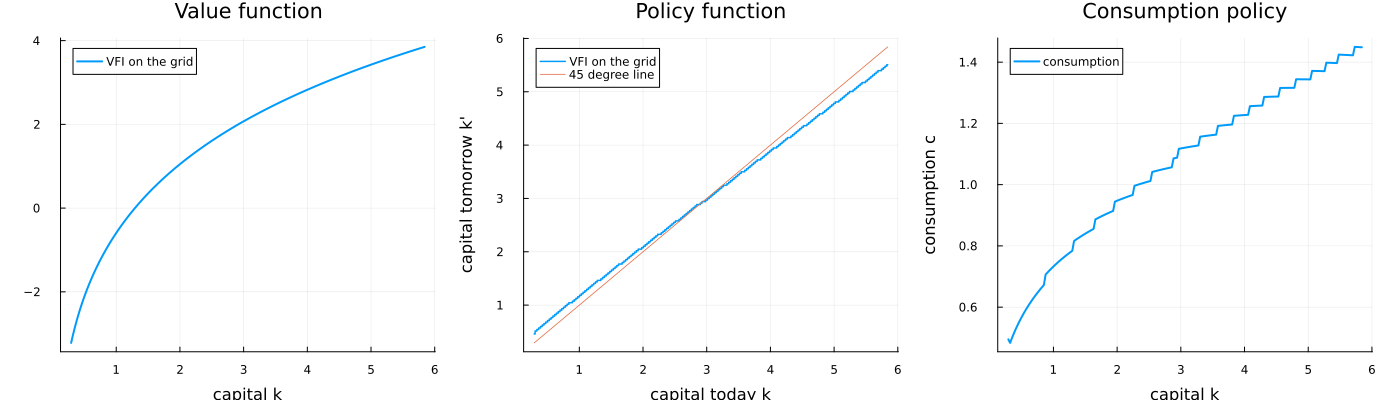

In [14]:
print_parameters(par_general, mpar_general, sol_general)

p1 = plot(
    sol_general.K,
    sol_general.v,
    linewidth = 2,
    label = "VFI on the grid",
    xlabel = "capital k",
    title = "Value function"
)

p2 = plot(
    sol_general.K,
    sol_general.kprime,
    seriestype = :stepmid,
    linewidth = 1.5,
    label = "VFI on the grid",
    xlabel = "capital today k",
    ylabel = "capital tomorrow k'",
    title = "Policy function"
)

plot!(
    p2,
    sol_general.K,
    sol_general.K,
    linewidth = 0.8,
    label = "45 degree line"
)

p3 = plot(
    sol_general.K,
    sol_general.c,
    linewidth = 2,
    label = "consumption",
    xlabel = "capital k",
    ylabel = "consumption c",
    title = "Consumption policy"
)

plot(
    p1, p2, p3,
    layout = (1, 3),
    size = (1400, 400),
    margin = 5Plots.mm
)

### 2.1(f) Steady-state crossing and Euler-error location

In [15]:
print_parameters(par_general, mpar_general, sol_general)

icross = argmin(abs.(sol_general.kprime .- sol_general.K))

@printf(
    "policy closest to 45 degree line at k = %.6f\n",
    sol_general.K[icross]
)

@printf(
    "k* = %.6f\n",
    sol_general.kstar
)

@printf(
    "difference = %.6e\n",
    abs(sol_general.K[icross] - sol_general.kstar)
)

Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 2.0, delta = 0.1, N = 200, crit = 1.0e-6
iterations: 226, final distance: 9.804e-07
policy at the lowest grid point: 0 states
policy at the highest grid point: 0 states
policy closest to 45 degree line at k = 2.885596
k* = 2.920822
difference = 3.522600e-02


The policy crosses the 45° line at about $k=2.8856$, close to the theoretical steady state $k^*=2.9208$. The difference is about $0.0352$, which reflects the fact that the on-grid policy can only choose discrete grid points. The largest Euler equation error occurs near the lower end of the grid, at $k=0.2921$, where the policy is more curved and the discretization error from restricting $k'$ to the grid is relatively more important.

## 2.2 Simulation, the cost of the grid, and risk aversion

### 2.2(a) Simulation from $k_0 = 0.5k^*$

In [16]:
print_parameters(par_general, mpar_general, sol_general)

T = 300
k0 = 0.5 * sol_general.kstar

# Initial grid index: point in K closest to k0
i0 = argmin(abs.(sol_general.K .- k0))

# Store grid indices and capital path
indices = zeros(Int, T + 1)
k_path = zeros(T + 1)

indices[1] = i0
k_path[1] = sol_general.K[i0]

# Simulate by repeatedly applying the policy index g
for t in 1:T
    indices[t + 1] = sol_general.g[indices[t]]
    k_path[t + 1] = sol_general.K[indices[t + 1]]
end

settle_k = k_path[end]
settle_gap = abs(settle_k - sol_general.kstar)

@printf("initial target k0 = %.6f\n", k0)
@printf("initial grid point = %.6f\n", k_path[1])
@printf("path settles at k = %.6f\n", settle_k)
@printf("distance from k* = %.6e\n", settle_gap)

Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 2.0, delta = 0.1, N = 200, crit = 1.0e-6
iterations: 226, final distance: 9.804e-07
policy at the lowest grid point: 0 states
policy at the highest grid point: 0 states
initial target k0 = 1.460411
initial grid point = 1.463347
path settles at k = 2.885596
distance from k* = 3.522600e-02


Starting from $k_0=0.5k^*=1.460411$, the closest grid point is $1.463347$. The simulated path settles at $k=2.885596$, which is $0.035226$ below the theoretical steady state $k^*=2.920822$.

Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 2.0, delta = 0.1, N = 200, crit = 1.0e-6
iterations: 226, final distance: 9.804e-07
policy at the lowest grid point: 0 states
policy at the highest grid point: 0 states


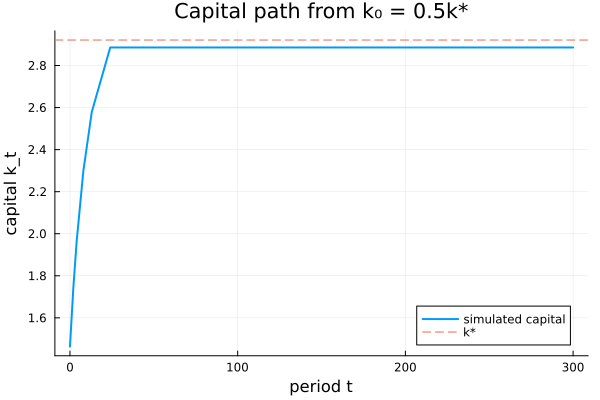

In [17]:
print_parameters(par_general, mpar_general, sol_general)

plot(
    0:T,
    k_path,
    linewidth = 2,
    label = "simulated capital",
    xlabel = "period t",
    ylabel = "capital k_t",
    title = "Capital path from k₀ = 0.5k*"
)

hline!(
    [sol_general.kstar],
    linewidth = 1,
    linestyle = :dash,
    label = "k*"
)

### 2.2(b) Grid size, accuracy, and run time

In [18]:
Ns = [50, 200, 800]

results_22b = []

for N in Ns

    par_N = EconomicParameters(
        α = 0.3,
        β = 0.96,
        γ = 2.0,
        δ = 0.1
    )

    mpar_N = NumericalParameters(
        nk = N,
        crit = 1e-6
    )

    sol_N = solve_vfi(par_N, mpar_N)

    e_N = euler_errors(sol_N, par_N)

    # Grid spacing
    grid_spacing = sol_N.K[2] - sol_N.K[1]

    # Simulate 300 periods from k0 = 0.5 k*
    T = 300
    k0_N = 0.5 * sol_N.kstar
    i0_N = argmin(abs.(sol_N.K .- k0_N))

    idx_N = i0_N

    for t in 1:T
        idx_N = sol_N.g[idx_N]
    end

    settle_N = sol_N.K[idx_N]

    push!(
        results_22b,
        (   par = par_N,
            mpar = mpar_N,
            sol = sol_N,
            N = N,
            grid_spacing = grid_spacing,
            iterations = sol_N.iterations,
            runtime = sol_N.runtime,
            max_euler_error = maximum(abs.(e_N)),
            settling_point = settle_N
        )
    )
end

Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 2.0, delta = 0.1, N = 50, crit = 1.0e-6
iterations: 230, final distance: 9.667e-07, time: 0.003 s
policy at the lowest grid point:  0 states
policy at the highest grid point: 0 states
Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 2.0, delta = 0.1, N = 200, crit = 1.0e-6
iterations: 226, final distance: 9.804e-07, time: 0.074 s
policy at the lowest grid point:  0 states
policy at the highest grid point: 0 states
Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 2.0, delta = 0.1, N = 800, crit = 1.0e-6
iterations: 226, final distance: 9.622e-07, time: 1.012 s
policy at the lowest grid point:  0 states
policy at the highest grid point: 0 states


In [19]:
for r in results_22b
    print_parameters(r.par, r.mpar, r.sol)
end

println("Results from the three VFI runs above:")

println(
    rpad("N", 8),
    rpad("grid spacing", 18),
    rpad("iterations", 14),
    rpad("run time", 14),
    rpad("max |e_i|", 18),
    "settling point"
)

for r in results_22b
    @printf(
        "%-8d %-18.6e %-14d %-14.6f %-18.6e %.6f\n",
        r.N,
        r.grid_spacing,
        r.iterations,
        r.runtime,
        r.max_euler_error,
        r.settling_point
    )
end

for j in 2:length(results_22b)
    previous = results_22b[j - 1]
    current = results_22b[j]

    @printf(
        "N = %d -> %d: runtime factor = %.2f (quadratic prediction = %.2f); Euler-error reduction = %.2f\n",
        previous.N,
        current.N,
        current.runtime / previous.runtime,
        (current.N / previous.N)^2,
        previous.max_euler_error / current.max_euler_error
    )
end

Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 2.0, delta = 0.1, N = 50, crit = 1.0e-6
iterations: 230, final distance: 9.667e-07
policy at the lowest grid point: 0 states
policy at the highest grid point: 0 states
Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 2.0, delta = 0.1, N = 200, crit = 1.0e-6
iterations: 226, final distance: 9.804e-07
policy at the lowest grid point: 0 states
policy at the highest grid point: 0 states
Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 2.0, delta = 0.1, N = 800, crit = 1.0e-6
iterations: 226, final distance: 9.622e-07
policy at the lowest grid point: 0 states
policy at the highest grid point: 0 states
Results from the three VFI runs above:
N       grid spacing      iterations    run time      max |e_i|         settling point
50       1.132564e-01       230            0.003401       1.653191e-01       2.783722
200      2.788725e-02       226            0.073748      

The grid spacing falls approximately in proportion to $1/N$. When $N$ increases from 200 to 800, the grid becomes four times finer and the maximum Euler error falls from $4.56\times10^{-2}$ to $1.11\times10^{-2}$, also by roughly a factor of four. This is consistent with

$
\max_i |e_i| = O(N^{-1}).
$

The Bellman step compares every current grid point with every possible next-period grid point, so the computational work per iteration is $O(N^2)$. Since the number of iterations is essentially unchanged, total run time should also scale approximately as $O(N^2)$. Each fourfold increase in N therefore predicts a sixteenfold increase in runtime. The measured runtime factors and Euler-error reduction factors are printed above. Timing noise and allocation overhead cause deviations from the runtime prediction, especially for the shortest runs; the Euler-error reductions of approximately 3.62 and 4.11 support O(N⁻¹) error scaling.

### 2.2(c) Extrapolation to an Euler error below $10^{-4}$

In [20]:
r800 = results_22b[end]
print_parameters(r800.par, r800.mpar, r800.sol)

N_target = r800.N * (r800.max_euler_error / 1e-4)
runtime_target = r800.runtime * (N_target / r800.N)^2

@printf(
    "N estimate = %d * (%.8e / 1e-4) = %.0f\n",
    r800.N, r800.max_euler_error, N_target
)

@printf(
    "Time estimate = %.6f * (%.2f / %d)^2 = %.0f seconds = %.2f hours\n",
    r800.runtime,
    N_target,
    r800.N,
    runtime_target,
    runtime_target / 3600
)

Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 2.0, delta = 0.1, N = 800, crit = 1.0e-6
iterations: 226, final distance: 9.622e-07
policy at the lowest grid point: 0 states
policy at the highest grid point: 0 states
N estimate = 800 * (1.11080281e-02 / 1e-4) = 88864
Time estimate = 1.011588 * (88864.22 / 800)^2 = 12482 seconds = 3.47 hours


Using $O(N^{-1})$, Euler-error scaling gives approximately $88,900$ grid points for a target error of $10^{-4}$. The arithmetic above extrapolates runtime using $O(N^2)$ scaling and the measured $N = 800$ runtime from this run. The resulting estimate in seconds and hours is printed above.

### 2.2(d) Risk aversion and transition paths

In [21]:
function simulate_path(sol; T = 300, k0 = 0.5 * sol.kstar)

    i0 = argmin(abs.(sol.K .- k0))

    indices = zeros(Int, T + 1)
    k_path = zeros(T + 1)

    indices[1] = i0
    k_path[1] = sol.K[i0]

    for t in 1:T
        indices[t + 1] = sol.g[indices[t]]
        k_path[t + 1] = sol.K[indices[t + 1]]
    end

    return k_path
end

simulate_path (generic function with 1 method)

In [22]:
gammas = [1.0, 2.0, 5.0]

solutions_gamma = Dict()
paths_gamma = Dict()
periods_5pct = Dict()

for gamma in gammas

    par_gamma = EconomicParameters(
        α = 0.3,
        β = 0.96,
        γ = gamma,
        δ = 0.1
    )

    mpar_gamma = NumericalParameters(
        nk = 800,
        crit = 1e-6
    )

    sol_gamma = solve_vfi(par_gamma, mpar_gamma)

    k_path_gamma = simulate_path(sol_gamma)

    solutions_gamma[gamma] = sol_gamma
    paths_gamma[gamma] = k_path_gamma

    # First period in which capital is within 5% of k*
    within_5pct =
        abs.(k_path_gamma .- sol_gamma.kstar) ./ sol_gamma.kstar .<= 0.05

    first_index = findfirst(within_5pct)

    # Julia index 1 corresponds to period t = 0
    periods_5pct[gamma] = first_index - 1
end

Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 1.0, delta = 0.1, N = 800, crit = 1.0e-6
iterations: 156, final distance: 9.735e-07, time: 0.485 s
policy at the lowest grid point:  0 states
policy at the highest grid point: 0 states
Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 2.0, delta = 0.1, N = 800, crit = 1.0e-6
iterations: 226, final distance: 9.622e-07, time: 0.676 s
policy at the lowest grid point:  0 states
policy at the highest grid point: 0 states
Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 5.0, delta = 0.1, N = 800, crit = 1.0e-6
iterations: 247, final distance: 9.657e-07, time: 0.971 s
policy at the lowest grid point:  0 states
policy at the highest grid point: 0 states


In [23]:
for gamma in gammas
    par_report = EconomicParameters(
        α = 0.3,
        β = 0.96,
        γ = gamma,
        δ = 0.1
    )
    mpar_report = NumericalParameters(nk = 800, crit = 1e-6)

    print_parameters(
        par_report,
        mpar_report,
        solutions_gamma[gamma]
    )
end

println("Periods until capital is within 5% of k*:")

for gamma in gammas
    @printf(
        "gamma = %.1f: %d periods\n",
        gamma,
        periods_5pct[gamma]
    )
end

Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 1.0, delta = 0.1, N = 800, crit = 1.0e-6
iterations: 156, final distance: 9.735e-07
policy at the lowest grid point: 0 states
policy at the highest grid point: 0 states
Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 2.0, delta = 0.1, N = 800, crit = 1.0e-6
iterations: 226, final distance: 9.622e-07
policy at the lowest grid point: 0 states
policy at the highest grid point: 0 states
Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 5.0, delta = 0.1, N = 800, crit = 1.0e-6
iterations: 247, final distance: 9.657e-07
policy at the lowest grid point: 0 states
policy at the highest grid point: 0 states
Periods until capital is within 5% of k*:
gamma = 1.0: 15 periods
gamma = 2.0: 22 periods
gamma = 5.0: 37 periods


Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 1.0, delta = 0.1, N = 800, crit = 1.0e-6
iterations: 156, final distance: 9.735e-07
policy at the lowest grid point: 0 states
policy at the highest grid point: 0 states
Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 2.0, delta = 0.1, N = 800, crit = 1.0e-6
iterations: 226, final distance: 9.622e-07
policy at the lowest grid point: 0 states
policy at the highest grid point: 0 states
Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 5.0, delta = 0.1, N = 800, crit = 1.0e-6
iterations: 247, final distance: 9.657e-07
policy at the lowest grid point: 0 states
policy at the highest grid point: 0 states


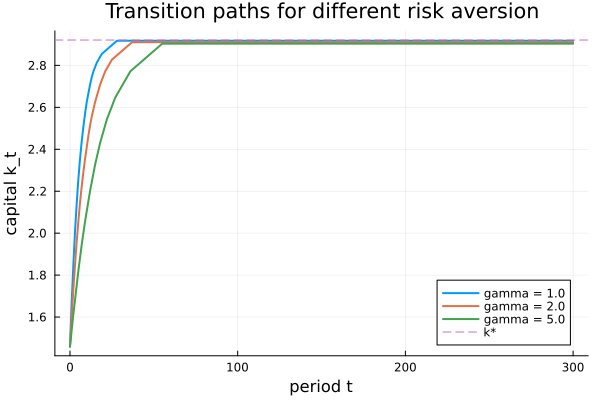

In [24]:
for gamma in gammas
    par_report = EconomicParameters(
        α = 0.3,
        β = 0.96,
        γ = gamma,
        δ = 0.1
    )
    mpar_report = NumericalParameters(nk = 800, crit = 1e-6)

    print_parameters(
        par_report,
        mpar_report,
        solutions_gamma[gamma]
    )
end

p_gamma = plot(
    xlabel = "period t",
    ylabel = "capital k_t",
    title = "Transition paths for different risk aversion"
)

for gamma in gammas
    plot!(
        p_gamma,
        0:300,
        paths_gamma[gamma],
        linewidth = 2,
        label = "gamma = $(gamma)"
    )
end

hline!(
    p_gamma,
    [solutions_gamma[2.0].kstar],
    linestyle = :dash,
    linewidth = 1,
    label = "k*"
)

p_gamma

### 2.2(e) Risk aversion, intertemporal substitution, and saving rates

In [25]:
for gamma in gammas
    par_report = EconomicParameters(
        α = 0.3,
        β = 0.96,
        γ = gamma,
        δ = 0.1
    )
    mpar_report = NumericalParameters(nk = 800, crit = 1e-6)

    print_parameters(
        par_report,
        mpar_report,
        solutions_gamma[gamma]
    )
end

println(
    rpad("gamma", 10),
    rpad("IES = 1/gamma", 18),
    "saving rate at k0"
)

for gamma in gammas

    sol_gamma = solutions_gamma[gamma]

    k0_target = 0.5 * sol_gamma.kstar
    i0 = argmin(abs.(sol_gamma.K .- k0_target))

    k0_grid = sol_gamma.K[i0]
    kprime0 = sol_gamma.kprime[i0]

    saving_rate =
        (kprime0 - (1 - 0.1) * k0_grid) /
        (k0_grid^0.3)

    @printf(
        "%-10.1f %-18.6f %.6f\n",
        gamma,
        1 / gamma,
        saving_rate
    )
end

Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 1.0, delta = 0.1, N = 800, crit = 1.0e-6
iterations: 156, final distance: 9.735e-07
policy at the lowest grid point: 0 states
policy at the highest grid point: 0 states
Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 2.0, delta = 0.1, N = 800, crit = 1.0e-6
iterations: 226, final distance: 9.622e-07
policy at the lowest grid point: 0 states
policy at the highest grid point: 0 states
Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 5.0, delta = 0.1, N = 800, crit = 1.0e-6
iterations: 247, final distance: 9.657e-07
policy at the lowest grid point: 0 states
policy at the highest grid point: 0 states
gamma     IES = 1/gamma     saving rate at k0
1.0        1.000000           0.316311
2.0        0.500000           0.254296
5.0        0.200000           0.198482


The household with $\gamma=1$ reaches the steady state fastest: it enters the five-percent neighborhood of $k^*$ after 15 periods, compared with 22 periods for $\gamma=2$ and 37 periods for $\gamma=5$.

The intertemporal elasticity of substitution is $1/\gamma$, so it falls from $1$ to $0.5$ to $0.2$ as $\gamma$ rises. A lower elasticity means the household is less willing to shift consumption across time in response to intertemporal returns.

At the initial state $k_0=0.5k^*$, the saving rate is $0.3163$ for $\gamma=1$, $0.2543$ for $\gamma=2$, and $0.1985$ for $\gamma=5$. Thus, in these simulations, higher $\gamma$ is associated with a lower initial saving rate and a slower accumulation of capital toward the steady state.